This notebook contains a computation of the nonlinear memory effect based on the polarizations $h_+$ and $h_\times$ given by PyCBC and the comparison with the memory given by the package `gwmemory`


### 1. Personal method 

We assumed that the $h_{22}$ mode is the dominant one, so we can use the following formula to compute the memory effect:
\begin{equation}
h^{\text{mem}}_{+}(t) = \frac{r}{192\pi} \sin^2{\theta}(17+ \cos^2{\theta}) \int_{-\infty}^{t_r} |\dot{h}_{22}(t')|^2 dt'
\end{equation}
where $\theta$ is the inclination angle ( 0 for North Pole and $\pi$ for South Pole), $r$ is the distance to the source and $h_{22}$ is the $(l=2, m=2)$ mode of the GW strain. The time $t_r$ is the retarded time defined as $t_r = t - r/c$, expressing the fact that the GW signal takes some time to reach the observer located at a distance $r$ from the source.

The mode $h_{22}$ can be obtained from the polarizations $h_+$ and $h_\times$ using the following relation:
\begin{equation}
h_+ - i h_\times = \sum_{l=2}^{\infty} \sum_{m=-l}^{l} h_{lm} \, {}_{-2}Y_{lm}(\theta, \phi)
\end{equation}
where ${}_{-2}Y_{lm}(\theta, \phi)$ are the spin-weighted spherical harmonics with spin weight -2 for the angles $\theta$ and $\phi$ defining the direction of the observer : $\theta$ is the inclination angle and $\phi$ is the azimuthal angle.

Assuming the dominant mode is $h_{22}$ only, we have:
\begin{equation}
h_{22} = \frac{h_+ - i h_\times}{{}_{-2}Y_{22}(\theta, \phi)}
\end{equation}
We can then compute the time derivative of $h_{22}$ numerically and perform the integration to obtain the memory effect.

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, MTSUN_SI, PC_SI, C_SI, G_SI
from pycbc.waveform import get_td_waveform

We define our spin-weighted spherical harmonic function as follows:

In [93]:
# Definition based on the article : https://arxiv.org/pdf/0812.0069#page=5.61
def fac(n): 
    if n==0 or n==1:
        return 1
    result = 1
    for i in range(2, n+1):
        result *= i
    return result

def dlms(l, m, s, Theta): # eq (2.14)
    fact1 = np.sqrt(fac(l+m)*fac(l-m)*fac(l+s)*fac(l-s))
    fact2 = 0.
    for k in range(max(0,m-s),min(l+m,l-s)+1):
        fact2 += (-1.)**k*np.sin(Theta/2.)**(2.*k+s-m)*np.cos(Theta/2.)**(2.*l+m-s-2.*k)/(fac(k)*fac(l+m-k)*fac(l-s-k)*fac(s-m+k))
    return fact1*fact2

def sYlm(s,l,m,Theta,Phi): # eq (2.13)
    fact = (-1.)**(-s)*np.sqrt((2.*l+1)/(4*np.pi))*dlms(l,m,-s,Theta)
    if fact==0:
        return 0.
    else:
        return complex(fact*np.cos(m*Phi), fact*np.sin(m*Phi)) # e^(imPhi)

These functions aim to compute the memory effect based on the dominant $h_{22}$ mode extracted from the polarizations $h_+$ and $h_\times$ of PyCBC waveforms for a extended waveform with a mass ratio of 1.

In [94]:
def generate_waveform_extended(mtot, deltaT, distance, inclination, approximant, extension_time=0.2):
    """
    Generate a waveform  with post-merger extension 
    """
    m1 = m2 = mtot / 2.0


    hp, hc = get_td_waveform(
        approximant=approximant,
        mass1=m1, mass2=m2,
        delta_t=deltaT,
        f_lower=20.,
        distance=distance,
        inclination=inclination,
    )
    hp_orig = hp.numpy()
    hc_orig = hc.numpy()
    t_orig = hp.sample_times.numpy()

    # Align merger to t=0 by shifting time array
    amplitude = np.abs(hp_orig)
    merger_idx = np.argmax(amplitude)
    merger_time = t_orig[merger_idx]
    t_aligned = t_orig - merger_time

    # Extend waveform post-merger with zeros 
    n_extension = int(extension_time / deltaT)

    hp_extended = np.pad(hp_orig, (0, n_extension), mode='constant', constant_values=0)
    hc_extended = np.pad(hc_orig, (0, n_extension), mode='constant', constant_values=0)
    
    t_extension = np.arange(1, n_extension + 1) * deltaT + t_aligned[-1]
    t_extended = np.concatenate([t_aligned, t_extension])

    return t_extended, hp_extended, hc_extended


def generate_waveform_22(hp, hc, inclination, sqrt_two = False):
    """
    Compute the (2,2) mode from h+ and hx
    """
    h22 = (hp - 1.j * hc) / sYlm(-2, 2, 2, inclination, np.pi/2)
    if sqrt_two:
        h22 /= np.sqrt(2)
    return h22


def compute_memory_corrected(deltaT, h22, distance, inclination):
    """
    Compute the nonlinear memory effect from the h22 mode
    """
    dt = deltaT
    hdot = np.gradient(h22, dt)  
    hdot_c = np.conjugate(hdot)
    integrand = hdot * hdot_c
    cumint = np.cumsum(integrand) * dt  # Cumulative integral
    prefactor = (distance * 1e6 * PC_SI / C_SI) * (np.sin(inclination)) ** 2 * (17 + np.cos(inclination) ** 2) / (192 * np.pi)
    hmem = prefactor * cumint
    return np.real(hmem)

### 2. Using `gwmemory` package

We can compare our results with the memory effect computed using the `gwmemory` package, which provides a more comprehensive approach to calculating the memory effect by considering all relevant modes and contributions :

In [95]:
import gwmemory
total_mass = 60  # in solar masses
distance = 500  # in Mpc
inclination = np.pi / 2 # edge-on
delta_t = 1.0 / 4096  # time step in seconds
model_gwmemory = "IMRPhenomD"

t, hp_ext, hc_ext = generate_waveform_extended(
    mtot=total_mass,
    deltaT=delta_t,
    distance=distance,
    inclination=inclination,
    approximant="IMRPhenomD",
    extension_time=0.2
)
parameters = dict(
        total_mass=total_mass,
        distance=distance,
        inc=inclination,
        q=1.0,
        phase=0,
        spin_1=[0.0, 0.0, 0.0],
        spin_2=[0.0, 0.0, 0.0],
        times=t,
        model=model_gwmemory
        )


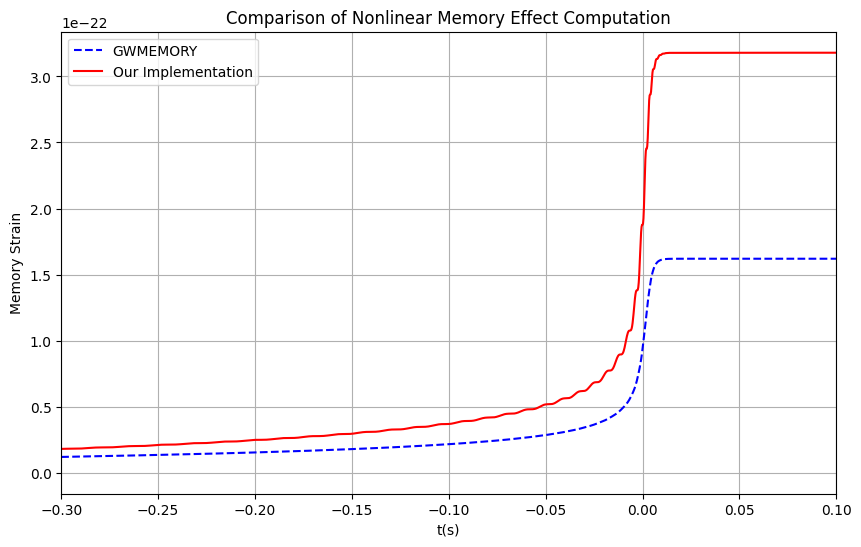

In [96]:
# Compute memory using gwmemory 
h_mem_gwmemory, t_mem_gwmemoy= gwmemory.time_domain_memory(**parameters)

# Compute memory using our implementation
h22 = generate_waveform_22(hp_ext, hc_ext, inclination)
h_mem_our = compute_memory_corrected(delta_t, h22, distance, inclination)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='red')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.3, 0.1)
plt.legend()
plt.grid()
plt.show()

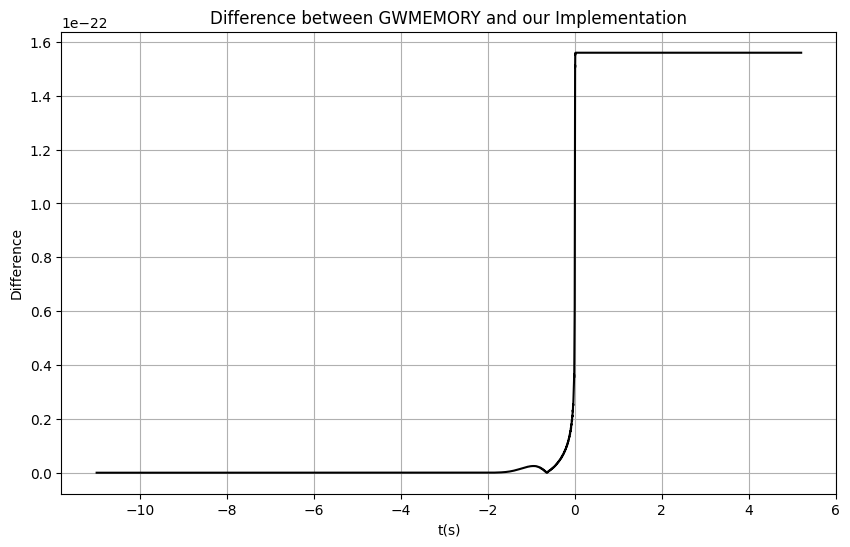

In [97]:
# Relative difference plot
relative_difference = np.abs(h_mem_our - h_mem_gwmemory['plus'])
plt.figure(figsize=(10, 6))
plt.plot(t, relative_difference, color='k')
plt.xlabel('t(s)')
plt.ylabel('Difference')
plt.title('Difference between GWMEMORY and our Implementation')
plt.grid()
plt.show()

But if we divide our h22 by a factor $\sqrt{2}$, we obtain a much better agreement between the two methods. This factor could come from a different normalization convention used in the definition of the spin-weighted spherical harmonics or in the waveform generation process. Further investigation would be needed to pinpoint the exact source of this discrepancy.

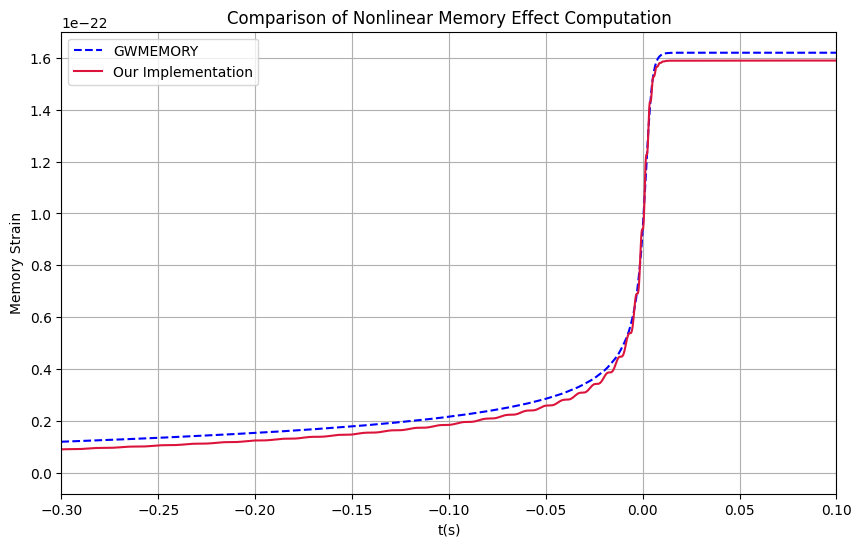

In [98]:
# Compute memory using our implementation
h22 = generate_waveform_22(hp_ext, hc_ext, inclination, sqrt_two=True)
h_mem_our = compute_memory_corrected(delta_t, h22, distance, inclination)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='crimson')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.3, 0.1)
plt.legend()
plt.grid()
plt.show()